#### Análise Exploratória de Dados: E-commerce Brasileiro (Olist)

**Objetivo:** Este notebook apresenta uma análise exploratória do conjunto de dados público da Olist, a maior loja de departamentos em marketplaces brasileiros. O foco é extrair insights acionáveis sobre logística, comportamento de pagamento, desempenho de produtos e satisfação do cliente para responder a perguntas estratégicas de negócio.

**Autores:** Kaike Brito Leitão e Enrico Santos Navajas

**Tecnologias Utilizadas:** Python, Pandas, Matplotlib

Total de pedidos analisados (Entregues): 96470
Pedidos no prazo: 88644
Pedidos em ATRASO: 7826 (8.11%)



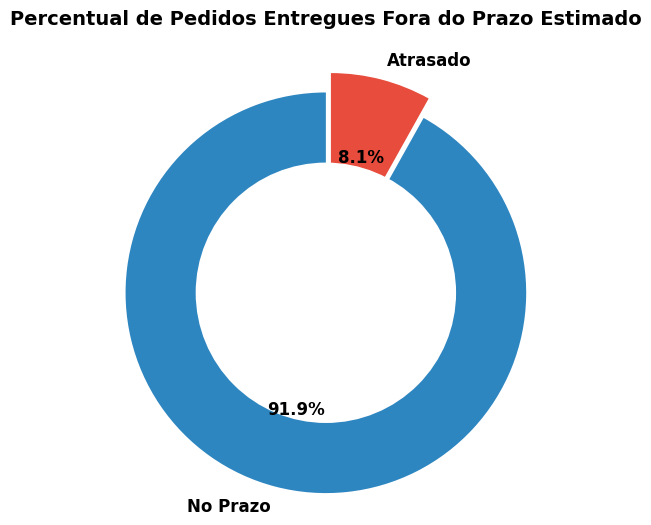

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Carregamento Seletivo
# ---------------------------------------------------------
# Carregamos apenas o dataset de pedidos, economizando memória
df_orders = pd.read_csv('dataframes/olist_orders_dataset.csv')

# ---------------------------------------------------------
# 2. Limpeza e Preparação de Dados (Mindset Sênior)
# ---------------------------------------------------------
# A regra de negócio exige avaliar apenas pedidos que chegaram ao cliente.
# O .copy() evita o aviso "SettingWithCopyWarning" do Pandas no futuro.
df_delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()

# O erro mais comum é não tipar as datas corretamente. Vamos converter strings para datetime.
df_delivered['order_delivered_customer_date'] = pd.to_datetime(df_delivered['order_delivered_customer_date'])
df_delivered['order_estimated_delivery_date'] = pd.to_datetime(df_delivered['order_estimated_delivery_date'])

# Remover eventuais linhas nulas nas datas de entrega para não distorcer o cálculo
df_delivered.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'], inplace=True)

# ---------------------------------------------------------
# 3. Lógica de Negócio e Cálculos
# ---------------------------------------------------------
# Criamos uma coluna booleana: True se a data real for maior que a estimada (Atraso)
df_delivered['atrasado'] = df_delivered['order_delivered_customer_date'] > df_delivered['order_estimated_delivery_date']

# Calculando as métricas
total_pedidos = len(df_delivered)
pedidos_atrasados = df_delivered['atrasado'].sum()
pedidos_no_prazo = total_pedidos - pedidos_atrasados

percentual_atraso = (pedidos_atrasados / total_pedidos) * 100

# Print rápido para validar os dados antes do gráfico
print(f"Total de pedidos analisados (Entregues): {total_pedidos}")
print(f"Pedidos no prazo: {pedidos_no_prazo}")
print(f"Pedidos em ATRASO: {pedidos_atrasados} ({percentual_atraso:.2f}%)\n")

# ---------------------------------------------------------
# 4. Visualização Estratégica (Matplotlib)
# ---------------------------------------------------------
labels = ['No Prazo', 'Atrasado']
valores = [pedidos_no_prazo, pedidos_atrasados]

# Uso de cores estratégicas: Azul (positivo/padrão corporativo) e Vermelho (alerta/negativo)
cores = ['#2E86C1', '#E74C3C'] 
explode = (0, 0.1) # Destaca levemente a fatia de "Atrasado" para chamar atenção no vídeo

fig, ax = plt.subplots(figsize=(8, 6))

# Criando o gráfico base
ax.pie(valores, explode=explode, labels=labels, colors=cores, autopct='%1.1f%%', 
       shadow=False, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})

# Truque Sênior: Adicionando um círculo branco no meio para transformar a Pizza em Rosca (Donut)
centro_circulo = plt.Circle((0,0), 0.65, fc='white')
fig.gca().add_artist(centro_circulo)

ax.axis('equal') # Garante proporção circular perfeita
plt.title('Percentual de Pedidos Entregues Fora do Prazo Estimado', fontsize=14, weight='bold', pad=20)

plt.show()

Frequência de uso por método de pagamento (Pedidos > R$ 150,00):
payment_type
Cartão de Crédito    25738
Boleto                5500
Voucher                479
Cartão de Débito       401
Name: count, dtype: int64 



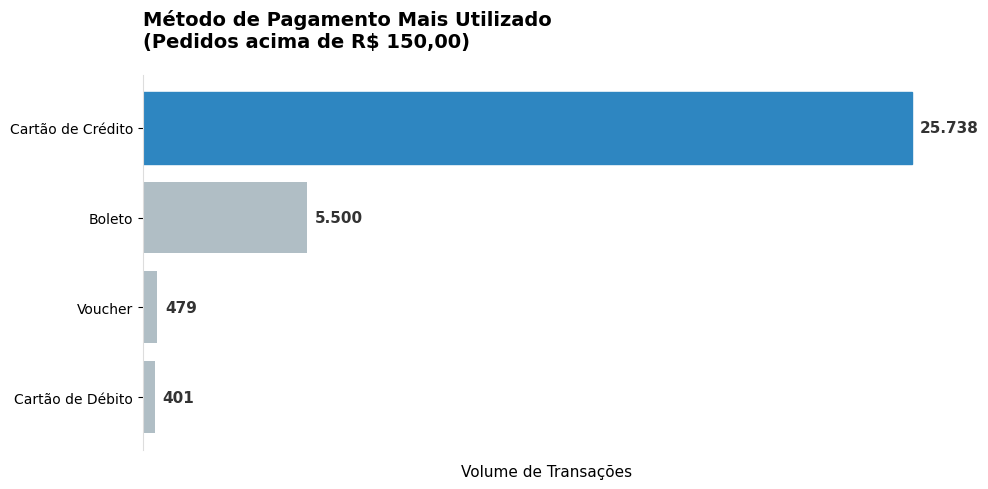

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Carregamento Seletivo
# ---------------------------------------------------------
# Precisamos apenas da tabela de pagamentos para esta pergunta
df_payments = pd.read_csv('dataframes/olist_order_payments_dataset.csv')

# ---------------------------------------------------------
# 2. Lógica de Negócio e Processamento
# ---------------------------------------------------------
# Filtrando apenas os pedidos cujo valor da parcela de pagamento é maior que R$ 150,00
df_high_value = df_payments[df_payments['payment_value'] > 150.00].copy()

# Agrupando por tipo de pagamento e contando a frequência (número de transações)
# O value_counts() já ordena do maior para o menor automaticamente
metodos_pagamento = df_high_value['payment_type'].value_counts()

# Dicionário para traduzir os métodos de pagamento para o gráfico (Capricho visual)
traducao_pagamentos = {
    'credit_card': 'Cartão de Crédito',
    'boleto': 'Boleto',
    'voucher': 'Voucher',
    'debit_card': 'Cartão de Débito',
    'not_defined': 'Não Definido'
}

# Aplicando a tradução aos índices (nomes das categorias)
metodos_pagamento.index = metodos_pagamento.index.map(traducao_pagamentos)

# Removendo 'Não Definido' caso apareça, para limpar o gráfico (opcional, mas recomendado)
if 'Não Definido' in metodos_pagamento:
    metodos_pagamento = metodos_pagamento.drop('Não Definido')

print("Frequência de uso por método de pagamento (Pedidos > R$ 150,00):")
print(metodos_pagamento, "\n")

# ---------------------------------------------------------
# 3. Visualização Estratégica (Matplotlib)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Criando barras horizontais invertendo a ordem para o maior ficar no topo do gráfico
bars = ax.barh(metodos_pagamento.index[::-1], metodos_pagamento.values[::-1], color='#B0BEC5')

# Destacando a barra principal (a mais utilizada, que ficará no topo) com a cor da Olist/Sucesso
bars[-1].set_color('#2E86C1') 

# Adicionando os valores exatos na ponta de cada barra (Facilita a leitura no vídeo)
for bar in bars:
    ax.text(bar.get_width() + (max(metodos_pagamento.values) * 0.01), # Posição X (um pouco à frente da barra)
            bar.get_y() + bar.get_height()/2, # Posição Y (meio da barra)
            f'{int(bar.get_width()):,}'.replace(',', '.'), # Formatação com ponto de milhar
            va='center', ha='left', fontsize=11, fontweight='bold', color='#333333')

# Limpeza visual (Removendo as bordas desnecessárias do gráfico)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')

# Removendo os ticks (tracinhos) do eixo X para deixar mais limpo, já que temos os rótulos de dados
ax.xaxis.set_ticks([])

plt.title('Método de Pagamento Mais Utilizado\n(Pedidos acima de R$ 150,00)', 
          fontsize=14, fontweight='bold', loc='left', pad=20)
plt.xlabel('Volume de Transações', fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Carregamento Seletivo (Apenas os ficheiros necessários)
# ---------------------------------------------------------
df_items = pd.read_csv('dataframes/olist_order_items_dataset.csv')
df_products = pd.read_csv('dataframes/olist_products_dataset.csv')
df_translation = pd.read_csv('dataframes/product_category_name_translation.csv') # Usamos para padronizar os nomes

# ---------------------------------------------------------
# 2. Junção de Dados (Merges/JOINs)
# ---------------------------------------------------------
# Primeiro Merge: Unimos os itens do pedido com as informações do produto
df_merged = pd.merge(df_items[['order_id', 'product_id', 'price']], 
                     df_products[['product_id', 'product_category_name']], 
                     on='product_id', 
                     how='inner')

# Segundo Merge: Unimos com a tabela de tradução para ter nomes limpos (opcional, mas recomendado)
# O inner join já remove produtos sem categoria definida
df_final = pd.merge(df_merged, 
                    df_translation, 
                    on='product_category_name', 
                    how='inner')

# ---------------------------------------------------------
# 3. Lógica de Negócio e Agrupamento
# ---------------------------------------------------------
# A coluna 'price' representa o valor do produto (receita). Não incluímos o frete ('freight_value') 
# pois frete é repassado à transportadora, não é receita de produto.

# Agrupamos pelo nome da categoria (em inglês, mas vamos traduzir/limpar no plot) e somamos o preço
receita_por_categoria = df_final.groupby('product_category_name_english')['price'].sum()

# Ordenamos de forma decrescente e extraímos o Top 5
top_5_categorias = receita_por_categoria.sort_values(ascending=False).head(5)

# Limpeza visual dos nomes (ex: 'bed_bath_table' -> 'Cama, Mesa e Banho')
# Como sabemos as top 5 de cor no Olist, podemos mapear para um Português perfeito
dicionario_categorias = {
    'health_beauty': 'Beleza e Saúde',
    'watches_gifts': 'Relógios e Presentes',
    'bed_bath_table': 'Cama, Mesa e Banho',
    'sports_leisure': 'Desporto e Lazer',
    'computers_accessories': 'Informática'
}

# Renomeando o índice do Top 5 com o dicionário
top_5_categorias.index = top_5_categorias.index.map(lambda x: dicionario_categorias.get(x, x.replace('_', ' ').title()))

print("Top 5 Categorias por Receita Total (R$):")
print(top_5_categorias.apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')), "\n")

# ---------------------------------------------------------
# 4. Visualização Estratégica (Matplotlib)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Gráfico de barras verticais. A primeira (maior receita) ganha a cor de destaque.
cores = ['#2E86C1', '#B0BEC5', '#B0BEC5', '#B0BEC5', '#B0BEC5']
bars = ax.bar(top_5_categorias.index, top_5_categorias.values, color=cores, width=0.6)

# Adicionando rótulos de dados (Data Labels) no topo de cada barra formatados em Moeda (R$)
for bar in bars:
    altura = bar.get_height()
    # Formatação complexa de string para colocar ponto de milhar e vírgula nos decimais
    valor_formatado = f'R$ {altura:,.0f}'.replace(',', '.')
    ax.text(bar.get_x() + bar.get_width()/2., altura + (max(top_5_categorias.values) * 0.02),
            valor_formatado, ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# Limpeza do gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_visible(False) # Removemos o eixo Y porque os valores já estão no topo das barras

plt.title('Top 5 Categorias de Produtos com Maior Receita Gerada', fontsize=15, fontweight='bold', pad=30)
plt.xticks(fontsize=11, rotation=0) # Rotação 0 deixa o texto reto e fácil de ler

plt.tight_layout()
plt.show()